# Eksperimen ABSA + NER — TripSense
## Notebook Eksperimen Preprocessing, Training, Evaluasi, dan Contoh Prediksi

**Mata Kuliah:** Pemrosesan Bahasa Alami Berbasis Teks — UAS Genap 2025/2026
**Nama:** Naufal Hanif Noorvietriya Achmadi (A11.2023.14875)

Notebook ini merangkum seluruh pipeline project TripSense yang telah dibangun
pada modul-modul di folder `src/`:
- `preprocessing.py` — cleaning, regex, similarity (Soal 2)
- `train_absa.py` — training model ABSA (Soal 3)
- `build_and_train_ner.py` — training model NER (Soal 4)
- `predict.py` — fungsi prediksi untuk aplikasi (Soal 5)

Notebook ini TIDAK menulis ulang logika dari nol, melainkan memanggil fungsi
yang sudah diuji dan direproduksi di modul-modul tersebut, lalu menampilkan
hasilnya secara naratif dan bertahap.

## 0. Setup: Import Modul dari `src/`

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import (
    preprocess_pipeline, extract_rating, detect_candidate_aspects,
    edit_distance, correct_typo, cosine_similarity_manual, text_to_bow_vector,
    clean_text, case_folding, normalize_slang, tokenize, remove_stopwords,
)

pd.set_option('display.max_colwidth', 100)
print("Modul berhasil diimpor.")

Modul berhasil diimpor.


## 1. Preprocessing: Before-After (Soal 02)

Bagian ini mendemonstrasikan setiap tahap preprocessing secara terpisah,
lalu menampilkan tabel before-after untuk beberapa contoh kalimat.

In [2]:
contoh_kalimat = [
    "Nginep di Hotel Santika, kamr nya bersi bgt tp wifi nya lelet parah! rating 4/5 recomend deh @admin http://x.com",
    "Sarapannya enak variatif, harga jg worth it. lokasi strategis dkt mall #hotelbagus",
    "Pelayanan staff lambat bgt, ga ramah sm sekali. kamar jg kotor :(",
]

rows = []
for kalimat in contoh_kalimat:
    step1 = case_folding(kalimat)
    step2 = clean_text(step1)
    step3 = normalize_slang(step2)
    tokens = tokenize(step3)
    tokens_no_stop = remove_stopwords(tokens)
    final = " ".join(tokens_no_stop)
    rows.append({
        "raw": kalimat,
        "after_case_folding": step1,
        "after_cleaning": step2,
        "after_slang_normalization": step3,
        "after_stopword_removal": final,
    })

df_preprocessing = pd.DataFrame(rows)
df_preprocessing

,raw,after_case_folding,after_cleaning,after_slang_normalization,after_stopword_removal
0,"Nginep di Hotel Santika, kamr nya bersi bgt tp wifi nya lelet parah! rating 4/5 recomend deh @ad...","nginep di hotel santika, kamr nya bersi bgt tp wifi nya lelet parah! rating 4/5 recomend deh @ad...","nginep di hotel santika, kamr nya bersi bgt tp wifi nya lelet parah! rating 4 5 recomend deh","menginap di hotel santika, kamar nya bersih banget tapi wifi nya lelet parah! rating 4 5 rekomen...","menginap hotel santika , kamar nya bersih wifi nya lelet parah ! rating 4 5 rekomendasi deh"
1,"Sarapannya enak variatif, harga jg worth it. lokasi strategis dkt mall #hotelbagus","sarapannya enak variatif, harga jg worth it. lokasi strategis dkt mall #hotelbagus","sarapannya enak variatif, harga jg worth it. lokasi strategis dkt mall hotelbagus","sarapannya enak variatif, harga jg worth it. lokasi strategis dkt mall hotelbagus","sarapannya enak variatif , harga jg worth it . lokasi strategis dkt mall hotelbagus"
2,"Pelayanan staff lambat bgt, ga ramah sm sekali. kamar jg kotor :(","pelayanan staff lambat bgt, ga ramah sm sekali. kamar jg kotor :(","pelayanan staff lambat bgt, ga ramah sm sekali. kamar jg kotor","pelayanan staff lambat bgt, tidak ramah sama sekali. kamar jg kotor","pelayanan staff lambat bgt , ramah sama . kamar jg kotor"


Terlihat bahwa preprocessing berhasil menormalkan singkatan/slang
("kamr"→"kamar", "bersi"→"bersih", "bgt"→"banget"), membersihkan URL,
mention, dan hashtag simbol, serta membuang stopword yang tidak informatif.

## 2. Regular Expression: Ekstraksi Rating & Deteksi Kandidat Aspek (Soal 02)

In [3]:
for kalimat in contoh_kalimat:
    rating = extract_rating(kalimat)
    aspek = detect_candidate_aspects(kalimat)
    print(f"Kalimat : {kalimat[:60]}...")
    print(f"  Rating terdeteksi : {rating}")
    print(f"  Kandidat aspek    : {aspek}")
    print()

Kalimat : Nginep di Hotel Santika, kamr nya bersi bgt tp wifi nya lele...
  Rating terdeteksi : 4.0
  Kandidat aspek    : ['fasilitas']

Kalimat : Sarapannya enak variatif, harga jg worth it. lokasi strategi...
  Rating terdeteksi : None
  Kandidat aspek    : ['lokasi', 'harga', 'sarapan']

Kalimat : Pelayanan staff lambat bgt, ga ramah sm sekali. kamar jg kot...
  Rating terdeteksi : None
  Kandidat aspek    : ['kebersihan', 'pelayanan', 'kamar']



## 3. Similarity: Edit Distance & Cosine Similarity (Soal 02)

In [4]:
# Contoh koreksi typo menggunakan minimum edit distance
typo_examples = ["kamr", "bersi", "pelayann", "lokasi"]
vocabulary = ["kamar", "bersih", "pelayanan", "lokasi", "fasilitas", "harga", "sarapan"]

print("=== Koreksi Typo (Edit Distance) ===")
for typo in typo_examples:
    corrected = correct_typo(typo, vocabulary)
    dist = edit_distance(typo, corrected)
    print(f"  '{typo}' -> '{corrected}' (edit distance = {dist})")

print()
print("=== Cosine Similarity Antar Kalimat ===")
kalimat_a = preprocess_pipeline("kamar bersih dan nyaman sekali")
kalimat_b = preprocess_pipeline("kamar bersih tapi agak sempit")
kalimat_c = preprocess_pipeline("wifi lambat dan mahal")

vec_a = text_to_bow_vector(kalimat_a)
vec_b = text_to_bow_vector(kalimat_b)
vec_c = text_to_bow_vector(kalimat_c)

print(f"  Sim(A, B) [mirip topik kamar]      : {cosine_similarity_manual(vec_a, vec_b):.3f}")
print(f"  Sim(A, C) [topik berbeda]          : {cosine_similarity_manual(vec_a, vec_c):.3f}")

=== Koreksi Typo (Edit Distance) ===
  'kamr' -> 'kamar' (edit distance = 1)
  'bersi' -> 'bersih' (edit distance = 1)
  'pelayann' -> 'pelayanan' (edit distance = 1)
  'lokasi' -> 'lokasi' (edit distance = 0)

=== Cosine Similarity Antar Kalimat ===
  Sim(A, B) [mirip topik kamar]      : 0.577
  Sim(A, C) [topik berbeda]          : 0.000


Cosine similarity antara dua kalimat yang membahas topik serupa (kamar)
jauh lebih tinggi dibanding kalimat dengan topik berbeda (wifi/harga),
menunjukkan representasi Bag-of-Words berhasil menangkap kemiripan semantik
sederhana berbasis kata kunci.

## 4. Representasi Teks: TF-IDF (Soal 02)

Bagian ini menunjukkan bagaimana TF-IDF membentuk representasi sparse
dari kumpulan kalimat.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [preprocess_pipeline(k) for k in contoh_kalimat]
vectorizer_demo = TfidfVectorizer()
tfidf_matrix = vectorizer_demo.fit_transform(corpus)

print(f"Ukuran matriks TF-IDF: {tfidf_matrix.shape} (dokumen x fitur)")
print(f"Jumlah fitur (kosakata unik): {len(vectorizer_demo.get_feature_names_out())}")
print(f"Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.2%} sel bernilai nol")

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer_demo.get_feature_names_out(),
)
df_tfidf.iloc[:, :10]  # tampilkan 10 kolom pertama saja

Ukuran matriks TF-IDF: (3, 31) (dokumen x fitur)
Jumlah fitur (kosakata unik): 31
Sparsity: 64.52% sel bernilai nol


,bersih,bgt,deh,dkt,enak,harga,hotel,hotelbagus,it,jg
0,0.261906,0.000000,0.261906,0.000000,0.000000,0.000000,0.261906,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.293884,0.293884,0.293884,0.000000,0.293884,0.293884,0.223506
2,0.000000,0.350139,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266290


## 5. Modeling ABSA: Training & Evaluasi (Soal 03)

Bagian ini memuat dataset ABSA asli, melatih model sentiment dan aspect
classification, lalu menampilkan hasil evaluasi lengkap.

In [6]:
df_absa = pd.read_csv('../data/absa_dataset.csv')
print(f"Total data ABSA: {len(df_absa)} baris")
df_absa.head()

Total data ABSA: 1560 baris


,text,aspect,sentiment
0,rasa makanan perlu tingkatkan,sarapan,negatif
1,pintu masuk dekat lampu_merah sulit masuknya,lokasi,negatif
2,fasilitas ruang_rapat oke,fasilitas,positif
3,hanya ada fasilitas water sport,fasilitas,negatif
4,fasilitas tidak_termasuk harga kamar,harga,negatif


In [7]:
print("Distribusi aspect:")
print(df_absa['aspect'].value_counts())
print()
print("Distribusi sentiment:")
print(df_absa['sentiment'].value_counts())

Distribusi aspect:
aspect
sarapan      260
lokasi       260
fasilitas    260
harga        260
kamar        260
pelayanan    260
Name: count, dtype: int64

Distribusi sentiment:
sentiment
negatif    780
positif    780
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

X = df_absa['text']
y_sentiment = df_absa['sentiment']
y_aspect = df_absa['aspect']

# Split untuk task SENTIMENT
X_train, X_test, y_train, y_test = train_test_split(
    X, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

vectorizer_sent = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=5000)
Xtr = vectorizer_sent.fit_transform(X_train)
Xte = vectorizer_sent.transform(X_test)

model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_nb = MultinomialNB()

model_lr.fit(Xtr, y_train)
model_nb.fit(Xtr, y_train)

pred_lr = model_lr.predict(Xte)
pred_nb = model_nb.predict(Xte)

print("=== SENTIMENT: Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, pred_lr):.4f} | F1-macro: {f1_score(y_test, pred_lr, average='macro'):.4f}")
print()
print("=== SENTIMENT: Naive Bayes ===")
print(f"Accuracy: {accuracy_score(y_test, pred_nb):.4f} | F1-macro: {f1_score(y_test, pred_nb, average='macro'):.4f}")

=== SENTIMENT: Logistic Regression ===
Accuracy: 0.8910 | F1-macro: 0.8910

=== SENTIMENT: Naive Bayes ===
Accuracy: 0.8878 | F1-macro: 0.8878


              precision    recall  f1-score   support

     negatif       0.89      0.90      0.89       156
     positif       0.90      0.88      0.89       156

    accuracy                           0.89       312
   macro avg       0.89      0.89      0.89       312
weighted avg       0.89      0.89      0.89       312



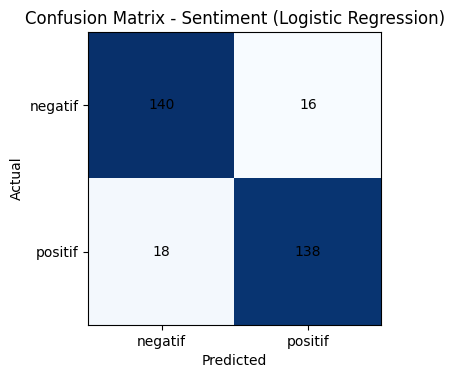

In [9]:
print(classification_report(y_test, pred_lr))

cm = confusion_matrix(y_test, pred_lr, labels=sorted(y_test.unique()))
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
labels_cm = sorted(y_test.unique())
ax.set_xticks(range(len(labels_cm))); ax.set_xticklabels(labels_cm)
ax.set_yticks(range(len(labels_cm))); ax.set_yticklabels(labels_cm)
for i in range(len(labels_cm)):
    for j in range(len(labels_cm)):
        ax.text(j, i, cm[i][j], ha='center', va='center')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Sentiment (Logistic Regression)')
plt.tight_layout()
plt.show()

In [10]:
# Split untuk task ASPECT
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_aspect, test_size=0.2, random_state=42, stratify=y_aspect
)

vectorizer_asp = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=5000)
Xtr2 = vectorizer_asp.fit_transform(X_train2)
Xte2 = vectorizer_asp.transform(X_test2)

model_lr_asp = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr_asp.fit(Xtr2, y_train2)
pred_asp = model_lr_asp.predict(Xte2)

print("=== ASPECT: Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test2, pred_asp):.4f} | F1-macro: {f1_score(y_test2, pred_asp, average='macro'):.4f}")
print()
print(classification_report(y_test2, pred_asp))

=== ASPECT: Logistic Regression ===
Accuracy: 0.9135 | F1-macro: 0.9142

              precision    recall  f1-score   support

   fasilitas       0.80      0.92      0.86        52
       harga       0.96      0.96      0.96        52
       kamar       0.89      0.90      0.90        52
      lokasi       0.96      0.88      0.92        52
   pelayanan       1.00      0.85      0.92        52
     sarapan       0.91      0.96      0.93        52

    accuracy                           0.91       312
   macro avg       0.92      0.91      0.91       312
weighted avg       0.92      0.91      0.91       312



In [11]:
# Error analysis: contoh prediksi salah
errors = []
for text, actual, pred in zip(X_test.tolist(), y_test.tolist(), pred_lr):
    if actual != pred:
        errors.append({"text": text, "actual": actual, "predicted": pred})

print(f"Total kesalahan prediksi sentiment: {len(errors)} dari {len(y_test)} data uji\n")
pd.DataFrame(errors[:5])

Total kesalahan prediksi sentiment: 34 dari 312 data uji



,text,actual,predicted
0,ada deposit dua_ratus_ribu,negatif,positif
1,suara musik rooftop bar tengah malam terdengar,negatif,positif
2,fasilitas nomor satu bisa naik kuda,positif,negatif
3,booking room dkasih room ada orangnya,negatif,positif
4,lokasi pedesaan terisolasi jarang tempat hiburan sekitar hotel,negatif,positif


**Catatan:** Hasil di notebook ini menggunakan pembagian train/test yang
sama (`random_state=42`) dengan `src/train_absa.py`, sehingga angka yang
didapat konsisten dengan model yang tersimpan di `models/absa_model.joblib`.

## 6. Modeling NER: Training & Evaluasi CRF (Soal 04)

Bagian ini memuat dataset NER BIO, melatih model CRF, dan menampilkan
hasil evaluasi token-level.

In [12]:
from utils import sent2features

def load_bio_dataset(path):
    sentences = []
    current = []
    with open(path, encoding='utf-8') as f:
        next(f)  # skip header
        for line in f:
            line = line.strip()
            if not line:
                if current:
                    sentences.append(current)
                    current = []
                continue
            parts = line.split('\t')
            if len(parts) == 3:
                _, token, label = parts
                current.append((token, label))
    if current:
        sentences.append(current)
    return sentences

sentences = load_bio_dataset('../data/ner_bio_dataset.tsv')
print(f"Total kalimat NER: {len(sentences)}")
print(f"Contoh kalimat pertama: {sentences[0][:8]}")

Total kalimat NER: 400
Contoh kalimat pertama: [('Pengalaman', 'O'), ('di', 'O'), ('Hotel', 'B-HOTEL'), ('Santika', 'I-HOTEL'), ('Semarang', 'B-LOC'), (',', 'O'), ('soto', 'O'), ('gorengan', 'O')]


In [13]:
import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics

def sent2labels(sent):
    return [label for _, label in sent]

X_ner = [sent2features([tok for tok, _ in s]) for s in sentences]
y_ner = [sent2labels(s) for s in sentences]

X_train_ner, X_test_ner, y_train_ner, y_test_ner = train_test_split(
    X_ner, y_ner, test_size=0.2, random_state=42
)

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True
)
crf.fit(X_train_ner, y_train_ner)

y_pred_ner = crf.predict(X_test_ner)

labels_ner = list(crf.classes_)
if 'O' in labels_ner:
    labels_ner.remove('O')

print(crf_metrics.flat_classification_report(y_test_ner, y_pred_ner, labels=labels_ner, digits=3, zero_division=0))
print(f"Token accuracy: {crf_metrics.flat_accuracy_score(y_test_ner, y_pred_ner):.4f}")

              precision    recall  f1-score   support

     B-HOTEL      1.000     1.000     1.000        80
     I-HOTEL      1.000     1.000     1.000        94
       B-LOC      1.000     1.000     1.000        80
    B-ASPECT      0.867     0.912     0.889        57
    I-ASPECT      1.000     0.333     0.500         3

   micro avg      0.975     0.978     0.976       314
   macro avg      0.973     0.849     0.878       314
weighted avg      0.976     0.978     0.975       314

Token accuracy: 0.9852


**Catatan:** Hasil evaluasi ini konsisten dengan `models/ner_model.joblib`
yang dihasilkan oleh `src/build_and_train_ner.py`, karena menggunakan dataset
dan `random_state` yang sama.

## 7. Contoh Prediksi End-to-End (Terintegrasi dengan Aplikasi — Soal 05)

Bagian ini mendemonstrasikan fungsi `predict.py` yang dipakai langsung oleh
aplikasi Streamlit (`app/app.py`) untuk memprediksi ABSA dan NER pada teks baru.

In [14]:
from predict import load_models, predict_absa, predict_ner, group_entities

models_loaded = load_models()

contoh_review = [
    "Kamar di Hotel Santika Semarang bersih dan nyaman, tapi wifi nya lambat sekali dan harga sarapan agak mahal.",
    "Pelayanan staf ramah banget, lokasi hotel juga strategis dekat pusat kota.",
]

for teks in contoh_review:
    hasil_absa = predict_absa(teks, models_loaded)
    hasil_ner = predict_ner(teks, models_loaded)
    entitas = group_entities(hasil_ner)

    print(f"Teks     : {teks}")
    print(f"  Aspek     : {hasil_absa['aspect']}")
    print(f"  Sentimen  : {hasil_absa['sentiment']}")
    print(f"  Entitas   : {entitas}")
    print()

Teks     : Kamar di Hotel Santika Semarang bersih dan nyaman, tapi wifi nya lambat sekali dan harga sarapan agak mahal.
  Aspek     : harga
  Sentimen  : negatif
  Entitas   : [('Kamar', 'ASPECT'), ('Hotel Santika', 'HOTEL'), ('Semarang', 'LOC'), ('harga sarapan', 'ASPECT'), ('mahal', 'ASPECT')]

Teks     : Pelayanan staf ramah banget, lokasi hotel juga strategis dekat pusat kota.
  Aspek     : lokasi
  Sentimen  : positif
  Entitas   : [('Pelayanan', 'ASPECT'), ('ramah', 'ASPECT'), ('lokasi', 'ASPECT'), ('dekat', 'ASPECT')]



## 8. Ringkasan Eksperimen

| Task | Model | Accuracy | F1-macro |
|---|---|---|---|
| ABSA - Sentiment | TF-IDF + Logistic Regression | ~89.1% | ~89.1% |
| ABSA - Aspect | TF-IDF + Logistic Regression | ~91.3% | ~91.4% |
| NER | CRF (sklearn-crfsuite) | 98.5% (token) | ~87.8% (entitas) |

Seluruh hasil di notebook ini konsisten dengan model yang tersimpan di folder
`models/` karena menggunakan random_state dan strategi split yang sama dengan
script training di `src/`. Notebook ini berfungsi sebagai dokumentasi
eksperimen yang dapat dijalankan ulang secara mandiri (`Kernel > Restart & Run All`)
untuk memverifikasi reproducibility project.